# Exp 04 — Seed-guided state-of-the-art graph 🌱→🕸️

Instead of discovering topics from scratch (exp_02) or from syntax (exp_03), this experiment lets the **seed paper's own citations define the lens**:

1. Take the seed document and resolve the arXiv papers in its **References** section.
2. Find **where the seed cites each reference** (author–year matching) — that citing context is *what the seed highlights about that reference*.
3. Ask **Qwen** (local Ollama) to turn each citing context into structured `{concepts, relations}`.
4. The aggregated concepts/relations become the **zero-shot labels for GLiNER**, which runs over every reference full text.
5. Merge everything into a knowledge graph where each concept is classified by how it relates to the seed vs. the state of the art (**core** / **seed-only** / **refs-only**).

```
seed.md ──## References──▶ arXiv IDs ──▶ local cache / arXiv fetch
   │                                          │
   └─ citing sentences (author-year) ─▶ Qwen ─▶ {concepts, relations} per ref
                                                 │
                                     aggregate ─▶ GLiNER labels
                                                 │
                     GLiNER over seed + every reference full text
                                                 │
                          knowledge graph: seed ⟷ state of the art
```

In [1]:
from pathlib import Path
from collections import Counter
import re

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import requests
from litellm import completion
from pydantic import BaseModel, Field
from tqdm.auto import tqdm

from kgraph.ingestion.references import ArxivReferenceExtractor
from kgraph.ingestion.arxiv import ArxivSource
from kgraph.graph.models import RawDocument
from kgraph.graph.config import build_pipeline_config
from kgraph.extractors.gliner import GLiNERGraph

# ---- experiment knobs -------------------------------------------------
SEED_ID        = "2404.16130"          # GraphRAG paper (rich, resolvable bibliography)
PAPERS_DIR     = Path("../data/papers")
CONFIG_PATH    = "../configs/params.yaml"
SEED_DOC_ID    = "__seed__"

MAX_REFS       = 15                    # cap on resolved references
FETCH_MISSING  = False                 # True -> download + docling-parse missing refs (slow)
MAX_CHARS      = 24_000                # full-text truncation per document (GLiNER is slow)

OLLAMA_MODEL   = "ollama/qwen3:0.6b"
OLLAMA_API_BASE = "http://localhost:11434"
KEEP_ALIVE     = "1m"                  # unload Qwen 10 min after its last call

TOP_CONCEPTS   = 15                    # taxonomy size handed to GLiNER
TOP_RELATIONS  = 8

STOPWORD_LABELS = {"the", "a", "an", "of", "and", "in", "on", "for", "with", "to"}

pd.set_option("display.max_colwidth", 100)

## 1 · Load the seed & resolve its references 📄

Docling renders each bibliography entry as a `- ` bullet under a `## References` heading. We parse those entries, map every `arXiv:<id>` we find to its entry, and cross-check with the repo's `ArxivReferenceExtractor`. References already parsed in `data/papers/*.md` are reused; anything else is only fetched from arXiv if `FETCH_MISSING=True` (PDF download + docling, slow).

We also cut every document at its References heading — cited titles inside a reference's own bibliography would pollute the extraction.

In [2]:
def find_local_md(arxiv_id):
    base = re.sub(r"v\d+$", "", arxiv_id)
    hits = sorted(PAPERS_DIR.glob(f"{base}*.md"))
    return hits[0] if hits else None

def split_at_references(text):
    m = re.search(r"^#{1,3}\s*References\s*$", text, flags=re.M)
    body = text[:m.start()] if m else text
    section = text[m.end():] if m else ""
    nxt = re.search(r"^#{1,3}\s+", section, flags=re.M)
    return body, (section[:nxt.start()] if nxt else section)

seed_path = next(PAPERS_DIR.glob(f"{SEED_ID}*.md"))
seed_text = seed_path.read_text()
seed_body, seed_ref_section = split_at_references(seed_text)

tm = re.search(r"^##\s+(.+)$", seed_text, flags=re.M)
seed_title = re.split(r"\s{2,}", tm.group(1).strip())[0] if tm else SEED_ID

# one string per bibliography entry ('- ' bullets; continuation lines join the previous entry)
entries, cur = [], []
for line in seed_ref_section.splitlines():
    s = line.strip()
    if not s:
        continue
    if s.startswith("- "):
        if cur:
            entries.append(" ".join(cur))
        cur = [s[2:].strip()]
    elif cur:
        cur.append(s)
    else:
        cur = [s]
if cur:
    entries.append(" ".join(cur))

entry_by_id = {}
for e in entries:
    for aid in re.findall(r"arXiv:?\s?(\d{4}\.\d{4,5})", e):
        entry_by_id.setdefault(aid, e)

resolved = ArxivReferenceExtractor().extract(seed_text, max_refs=MAX_REFS)
ref_ids = [re.sub(r"v\d+$", "", r.source_id) for r in resolved]
ref_ids = [rid for rid in dict.fromkeys(ref_ids) if rid in entry_by_id]

REFS_META = {SEED_DOC_ID: {"title": seed_title, "entry": "(the seed paper)"}}
for rid in ref_ids:
    mm = re.search(r"\(\d{4}\)\.\s*(.+?)\.(?:\s|$)", entry_by_id[rid])
    REFS_META[rid] = {"title": (mm.group(1).strip() if mm else entry_by_id[rid][:60]),
                      "entry": entry_by_id[rid]}

docs = {SEED_DOC_ID: RawDocument(id=SEED_DOC_ID, content=seed_body, source="exp04", metadata={"title": seed_title})}
for rid in ref_ids:
    path = find_local_md(rid)
    if path:
        body, _ = split_at_references(path.read_text())
        docs[rid] = RawDocument(id=rid, content=body, source="exp04_local", metadata=REFS_META[rid])
    elif FETCH_MISSING:
        fetched = ArxivSource(query=rid, max_results=1).fetch_fulltext(PAPERS_DIR)
        if fetched:
            docs[rid] = RawDocument(id=rid, content=fetched[0].content, source="exp04_arxiv", metadata=REFS_META[rid])

missing = [r for r in ref_ids if r not in docs]
print(f"Seed   : {seed_title!r} ({len(seed_body):,} chars)")
print(f"Refs   : {len(entries)} entries | {len(entry_by_id)} with arXiv id | {len(ref_ids)} selected")
print(f"Corpus : seed + {len(docs)-1} references ready ({len(missing)} unavailable: {missing or '-'})")

pd.DataFrame([{"arxiv_id": r, "title": REFS_META[r]["title"][:70], "in_corpus": r in docs} for r in ref_ids])

Seed   : 'From Local to Global: A GraphRAG Approach to Query-Focused Summarization' (48,208 chars)
Refs   : 79 entries | 30 with arXiv id | 14 selected
Corpus : seed + 14 references ready (0 unavailable: -)


,arxiv_id,title,in_corpus
0,1801.07704,Query focused abstractive summarization: Incorporating query relevance,True
1,2005.03975,Caire-covid: A question answering and query-focused multi-document sum,True
2,2009.08553,Generation-augmented retrieval for open-domain question answering,True
3,2106.00104,Text summarization with latent queries,True
4,2203.11171,Self-consistency improves chain of thought reasoning in language model,True
5,2212.10509,Interleaving retrieval with chain-of-thought reasoning for knowledge-i,True
6,2212.14024,Demonstrate-search-predict: Composing retrieval and language models fo,True
7,2303.04048,"Wang, J., Liang, Y., Meng, F., Sun, Z., Shi, H., Li, Z., Xu,",True
8,2303.08774,Gpt-4 technical report,True
9,2303.08896,Selfcheckgpt: Zero-resource black-box hallucination detection for gene,True


## 2 · Where does the seed cite each reference? 🔎

The seed cites author–year style — `(Achiam et al., 2023)` — so for every resolved reference we take its **first-author surname + year** from the bibliography entry and collect the seed sentences containing both. Those sentences are exactly *what the seed highlights about that reference*, which is the context we will feed Qwen.

`et al.` would wreck naive sentence splitting (it ends in a period), so it is masked while splitting.

In [3]:
def sentences(text):
    flat = re.sub(r"^#+\s+.*$", " ", text, flags=re.M)
    flat = flat.replace("et al.", "et al\u00a7")
    parts = re.split(r"(?<=[.!?])\s+(?=[A-Z\u2018\u201c(\u201c])", flat)
    return [p.replace("et al\u00a7", "et al.").strip() for p in parts if len(p.split()) > 3]

def author_year(entry):
    sm = re.match(r"^([A-Z][\w'\-]+)", entry)
    ym = re.search(r"\((\d{4})\)", entry)
    return (sm.group(1) if sm else None), (ym.group(1) if ym else None)

seed_sents = sentences(seed_body)

cite_ctx = {}
for rid in ref_ids:
    surname, year = author_year(entry_by_id[rid])
    cite_ctx[rid] = [s for s in seed_sents
                     if surname and year and re.search(rf"\b{re.escape(surname)}\b", s) and year in s]

df_cites = pd.DataFrame([
    {"arxiv_id": rid,
     "first_author": author_year(entry_by_id[rid])[0],
     "year": author_year(entry_by_id[rid])[1],
     "n_sentences": len(cite_ctx[rid]),
     "context_preview": (cite_ctx[rid][0][:110] + "...") if cite_ctx[rid] else "-"}
    for rid in ref_ids
])
display(df_cites)
matched = (df_cites["n_sentences"] > 0).sum()
print(f"{matched}/{len(ref_ids)} references matched to citing sentences; the rest fall back to the seed title.")

,arxiv_id,first_author,year,n_sentences,context_preview
0,1801.07704,Baumel,2018,1,The LLM then\n\ngenerates a response based on both the query and the retrieved records (Baumel e...
1,2005.03975,Su,2020,1,"These summaries are generated in parallel and iteratively aggregated into global summaries, simi..."
2,2009.08553,Mao,2020,1,GraphRAG leverages summaries over large sections of the data source as a form of 'self-memory' (...
3,2106.00104,Xu,2021,1,Our approach is related to LLM methods that use a corpus to generate questions whose answers wou...
4,2203.11171,Wang,2022,1,"These summaries are generated in parallel and iteratively aggregated into global summaries, simi..."
5,2212.10509,Trivedi,2022,1,"These summaries are generated in parallel and iteratively aggregated into global summaries, simi..."
6,2212.14024,Khattab,2022,1,"These summaries are generated in parallel and iteratively aggregated into global summaries, simi..."
7,2303.04048,Wang,NaN,0,-
8,2303.08774,Achiam,2023,1,"LLMs such as GPT (Achiam et al., 2023; Brown et al., 2020), Llama (Touvron et al., 2023), and Ge..."
9,2303.08896,Manakul,2023,1,"Comparison of fabrication rates, e.g., using approaches like SelfCheckGPT (Manakul et al., 2023)..."


13/14 references matched to citing sentences; the rest fall back to the seed title.


## 3 · Qwen extracts concepts & relations per reference 🧠

Each reference gets one structured call: *citing context + bibliography entry* → `{concepts[], relations[]}` (JSON-schema-constrained via LiteLLM).

**Keep-alive 🔋:** every call passes `keep_alive="10m"` to Ollama — the model stays warm for 10 minutes after its **last** request and then unloads itself automatically. So RAM/VRAM is freed while the notebook moves on to the CPU-heavy GLiNER stage, without anyone touching the server. The last cell force-unloads instantly with `keep_alive=0`.

In [4]:
import shutil
import subprocess
import time

_OLLAMA_PROC = None


def ensure_ollama(base=OLLAMA_API_BASE, wait_s=30):
    global _OLLAMA_PROC
    try:
        requests.get(f"{base}/api/tags", timeout=2).raise_for_status()
        print("Ollama already running ✓")
        return
    except requests.ConnectionError:
        pass
    ollama_bin = shutil.which("ollama")
    assert ollama_bin, "Ollama not installed - get it from https://ollama.com"
    _OLLAMA_PROC = subprocess.Popen(
        [ollama_bin, "serve"],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        start_new_session=True,
    )
    deadline = time.time() + wait_s
    while time.time() < deadline:
        try:
            requests.get(f"{base}/api/tags", timeout=2).raise_for_status()
            print(f"Ollama started in background (pid {_OLLAMA_PROC.pid})")
            return
        except requests.ConnectionError:
            time.sleep(0.5)
    raise RuntimeError(f"Ollama did not respond within {wait_s}s - try 'ollama serve' manually")


ensure_ollama()

class RefInsights(BaseModel):
    concepts: list[str] = Field(description="Key concepts this citing context highlights, max 3 words each")
    relations: list[str] = Field(description="Short relation phrases between concepts, e.g. 'outperforms', 'extends', 'is evaluated on'")

tags = requests.get(f"{OLLAMA_API_BASE}/api/tags", timeout=5)
tags.raise_for_status()
available = [m["name"] for m in tags.json().get("models", [])]
assert any(n.startswith(OLLAMA_MODEL.split("/")[-1]) for n in available), f"{OLLAMA_MODEL} not pulled - run: ollama pull {OLLAMA_MODEL.split('/')[-1]}"
print("Ollama OK:", ", ".join(available))

PROMPT_TEMPLATE = (
    'You analyze how the paper "{seed}" cites the reference "{ref}" ({surname}, {year}).\n\n'
    'Citing context from the seed paper:\n"""\n{context}\n"""\n\n'
    'Reference bibliography entry:\n"""\n{entry}\n"""\n\n'
    'List the key CONCEPTS (max 3 words each) and the RELATIONS (short verb '
    'phrases, max 3 words) that this citing context highlights.\n/no_think'
)

def qwen_insights(rid):
    surname, year = author_year(entry_by_id[rid])
    context = "\n".join(cite_ctx[rid][:4]) or f"The seed paper is: {seed_title}"
    prompt = PROMPT_TEMPLATE.format(
        seed=seed_title, ref=REFS_META[rid]["title"], surname=surname or "?", year=year or "?",
        context=context[:1500], entry=entry_by_id[rid][:400],
    ) 
    resp = completion(
        model=OLLAMA_MODEL,
        api_base=OLLAMA_API_BASE,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=500,
        timeout=120,
        response_format={
            "type": "json_schema",
            "json_schema": {"name": "RefInsights", "schema": RefInsights.model_json_schema()},
        },
        keep_alive=KEEP_ALIVE,
    )
    return RefInsights.model_validate_json(resp.choices[0].message.content)

insights = {}
for rid in tqdm([r for r in ref_ids if r in docs], desc="Qwen"):
    try:
        insights[rid] = qwen_insights(rid)
    except Exception as exc:
        print(f"{rid}: failed -> {exc}")

print(f"\n{len(insights)}/{len(ref_ids)} references analyzed")
print(insights)

Ollama already running ✓
Ollama OK: qwen3:0.6b


Qwen:   0%|          | 0/14 [00:00<?, ?it/s]

2212.10509: failed -> 1 validation error for RefInsights
  Invalid JSON: EOF while parsing a value at line 100 column 0 [type=json_invalid, input_value='{\n  "concepts": [\n    ...",\n    "seed paper",\n', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/json_invalid

13/14 references analyzed
{'1801.07704': RefInsights(concepts=['seq2seq models', 'query focused summarization', 'seq2seq'], relations=['involves', 'based on', 'from']), '2005.03975': RefInsights(concepts=['global summaries', 'query-focused', 'multi-document summarization'], relations=['similar to', 'iteratively', 'parallel']), '2009.08553': RefInsights(concepts=['self-memory', 'query-focused', 'summarization', 'graph', 'memory', 'source', 'data', 'source', 'summarization', 'graph', 'source'], relations=['self-memory', 'source', 'summarization', 'graph', 'memory', 'data', 'source', 'summarization', 'graph', 'source']), '2106.00104': RefInsights(concepts=['query', 'summarization', 'LLM'],

### 3.1 What Qwen saw in each citation

In [5]:
pd.DataFrame([
    {"arxiv_id": rid,
     "title": REFS_META[rid]["title"][:45],
     "concepts": ", ".join(ins.concepts),
     "relations": ", ".join(ins.relations)}
    for rid, ins in insights.items()
])

,arxiv_id,title,concepts,relations
0,1801.07704,Query focused abstractive summarization: Inco,"seq2seq models, query focused summarization, seq2seq","involves, based on, from"
1,2005.03975,Caire-covid: A question answering and query-f,"global summaries, query-focused, multi-document summarization","similar to, iteratively, parallel"
2,2009.08553,Generation-augmented retrieval for open-domai,"self-memory, query-focused, summarization, graph, memory, source, data, source, summarization, g...","self-memory, source, summarization, graph, memory, data, source, summarization, graph, source"
3,2106.00104,Text summarization with latent queries,"query, summarization, LLM","related to, in, with"
4,2203.11171,Self-consistency improves chain of thought re,"global summaries, iterative aggregation, chain of thought reasoning","global summaries are generated in parallel and iteratively aggregated into global summaries, the..."
5,2212.14024,Demonstrate-search-predict: Composing retriev,"global summaries, iterative aggregation, parallel processing","global summaries are generated in parallel and iteratively aggregated, the seed paper's approach..."
6,2303.04048,"Wang, J., Liang, Y., Meng, F., Sun, Z., Shi,","chatgpt, nlg, preliminary study","study, preliminary, a"
7,2303.08774,Gpt-4 technical report,"sensemaking, sensemaking in complex domains, sensemaking in scientific discovery","excell at, in, for"
8,2303.08896,Selfcheckgpt: Zero-resource black-box halluci,"Selfcheckgpt, black-box hallucination detection, generative large language models","strengthen, strengthened, supports"
9,2304.11116,Graph-toolformer: To empower llms with graph,"Graph reasoning, Graph structure, Prompt augmentation","uses subgraphs, directly in the prompt, factual grounding"


## 4 · Aggregate into a GLiNER taxonomy 🗂️

Concepts/relations are normalized (lowercase, punctuation stripped) and counted across references — **a label suggested by more references is more central to the state of the art**. The top-K of each become GLiNER's zero-shot `entity_labels` / `relation_labels`.

In [6]:
def norm_label(s):
    s = re.sub(r"[^a-z0-9 ]", " ", s.lower())
    return re.sub(r"\s+", " ", s).strip()

concept_counter, relation_counter = Counter(), Counter()
for ins in insights.values():
    concept_counter.update({norm_label(c) for c in ins.concepts} - STOPWORD_LABELS)
    relation_counter.update({norm_label(r) for r in ins.relations} - STOPWORD_LABELS)

entity_labels   = [c for c, _ in concept_counter.most_common(TOP_CONCEPTS)  if c]
relation_labels = [r for r, _ in relation_counter.most_common(TOP_RELATIONS) if r]

display(pd.DataFrame(concept_counter.most_common(TOP_CONCEPTS),  columns=["concept", "n_refs"]))
display(pd.DataFrame(relation_counter.most_common(TOP_RELATIONS), columns=["relation", "n_refs"]))
print(f"\nGLiNER labels -> entities: {entity_labels}\n               relations: {relation_labels}")

,concept,n_refs
0,global summaries,4
1,query focused,2
2,summarization,2
3,iterative aggregation,2
4,graph structure,2
5,seq2seq models,1
6,query focused summarization,1
7,seq2seq,1
8,multi document summarization,1
9,graph,1


,relation,n_refs
0,directly in the prompt,2
1,from,1
2,based on,1
3,involves,1
4,similar to,1
5,parallel,1
6,iteratively,1
7,summarization,1



GLiNER labels -> entities: ['global summaries', 'query focused', 'summarization', 'iterative aggregation', 'graph structure', 'seq2seq models', 'query focused summarization', 'seq2seq', 'multi document summarization', 'graph', 'memory', 'source', 'self memory', 'data', 'query']
               relations: ['directly in the prompt', 'from', 'based on', 'involves', 'similar to', 'parallel', 'iteratively', 'summarization']


## 5 · GLiNER hunts each document through its own lens 🎯

Each reference is extracted with **its own Qwen-derived labels** — exactly the concepts/relations the seed's citing context highlights about *that* paper — instead of one global taxonomy for everything. The seed gets the **union of all lenses** (it is the paper doing the citing), and a reference whose Qwen call failed falls back to the global top-K. `GLiNERGraph`'s canonical/embedding merging still collapses near-duplicate concepts across documents, so we can compare in *which* papers each concept survived.

Long papers are truncated to `MAX_CHARS` — enough signal for an experiment, sane runtime.

In [7]:
def doc_lens(rid):
    ins = insights.get(rid)
    ents = {norm_label(c) for c in ins.concepts} - STOPWORD_LABELS if ins else set()
    rels = {norm_label(r) for r in ins.relations} - STOPWORD_LABELS if ins else set()
    return list(ents), list(rels)


seed_ents = {norm_label(c) for ins in insights.values() for c in ins.concepts} - STOPWORD_LABELS
seed_rels = {norm_label(r) for ins in insights.values() for r in ins.relations} - STOPWORD_LABELS

cfg = build_pipeline_config(CONFIG_PATH, entities=entity_labels, relations=relation_labels)
cfg.ner.name = "../models/gliner-relex-large-v0.5"
cfg.entity_merging.model = "../models/all-MiniLM-L6-v2"

kg = GLiNERGraph(cfg)
per_doc_stats = []
for doc in tqdm(list(docs.values()), desc="GLiNER"):
    doc.content = doc.content[:MAX_CHARS]
    e_lab, r_lab = (seed_ents, seed_rels) if doc.id == SEED_DOC_ID else doc_lens(doc.id)
    e_lab = sorted(e_lab or entity_labels)
    r_lab = sorted(r_lab or relation_labels)
    ents, rels = kg.extract_from_document(doc, entity_labels=e_lab, relation_labels=r_lab)
    for e in ents:
        kg.add_entity(e)
    for r in rels:
        kg.add_relation(r)
    per_doc_stats.append({"doc": REFS_META[doc.id]["title"][:45], "labels": len(e_lab), "entities": len(ents), "relations": len(rels)})

display(pd.DataFrame(per_doc_stats))
print(kg.get_stats())

GLiNER:   0%|          | 0/15 [00:00<?, ?it/s]

/Users/albertovillamanrique/repositories/kgraph/backend/.venv/lib/python3.12/site-packages/gliner/data_processing/processor.py:1793: UserWarning: Sentence of length 4525 has been truncated to 1024
  self.preprocess_example(
/Users/albertovillamanrique/repositories/kgraph/backend/.venv/lib/python3.12/site-packages/gliner/data_processing/processor.py:1793: UserWarning: Sentence of length 4332 has been truncated to 1024
  self.preprocess_example(
/Users/albertovillamanrique/repositories/kgraph/backend/.venv/lib/python3.12/site-packages/gliner/data_processing/processor.py:1793: UserWarning: Sentence of length 4547 has been truncated to 1024
  self.preprocess_example(
/Users/albertovillamanrique/repositories/kgraph/backend/.venv/lib/python3.12/site-packages/gliner/data_processing/processor.py:1793: UserWarning: Sentence of length 4679 has been truncated to 1024
  self.preprocess_example(
/Users/albertovillamanrique/repositories/kgraph/backend/.venv/lib/python3.12/site-packages/gliner/data_p

,doc,labels,entities,relations
0,From Local to Global: A GraphRAG Approach to,36,44,60
1,Query focused abstractive summarization: Inco,3,5,0
2,Caire-covid: A question answering and query-f,3,10,12
3,Generation-augmented retrieval for open-domai,7,13,6
4,Text summarization with latent queries,3,11,10
5,Self-consistency improves chain of thought re,3,5,42
6,Interleaving retrieval with chain-of-thought,15,7,2
7,Demonstrate-search-predict: Composing retriev,3,0,0
8,"Wang, J., Liang, Y., Meng, F., Sun, Z., Shi,",3,5,6
9,Gpt-4 technical report,3,1,0


{'num_entities': 96, 'num_relations': 58, 'avg_degree': 1.2083333333333333}


## 6 · The graph: seed vs. state of the art 🕸️

Every concept is classified by where it survived:

| class | meaning |
| --- | --- |
| **core** | in the seed **and** ≥2 references — the shared state of the art |
| **seed-only** | claimed/used by the seed alone — its novelty surface |
| **refs-only** | background concepts the seed doesn't lean on |

In [8]:
node_rows = []
for nid, data in kg.graph.nodes(data=True):
    docs_of = {m["doc_id"] for m in data["mentions"]}
    n_refs = len(docs_of - {SEED_DOC_ID})
    klass = ("core" if (SEED_DOC_ID in docs_of and n_refs)
             else "seed-only" if SEED_DOC_ID in docs_of else "refs-only")
    node_rows.append({"concept": data["text"], "type": data["entity_type"], "score": round(data["score"], 2),
                      "n_docs": len(docs_of), "in_seed": SEED_DOC_ID in docs_of,
                      "degree": kg.graph.degree(nid), "klass": klass})

df_nodes = pd.DataFrame(node_rows).sort_values(["n_docs", "degree"], ascending=False).reset_index(drop=True)

df_edges = pd.DataFrame([
    {"head": kg.graph.nodes[u]["text"], "relation": d.get("relation_type"),
     "tail": kg.graph.nodes[v]["text"], "score": round(d["score"], 2), "count": d.get("count", 1)}
    for u, v, d in kg.graph.edges(data=True)
]).sort_values("score", ascending=False).reset_index(drop=True)

print(f"Graph: {kg.graph.number_of_nodes()} concept nodes, {kg.graph.number_of_edges()} relation edges\n")
print(df_nodes["klass"].value_counts().to_string())
display(df_nodes.head(20))
display(df_edges.head(15))

Graph: 96 concept nodes, 58 relation edges

klass
refs-only    62
seed-only    26
core          8


,concept,type,score,n_docs,in_seed,degree,klass
0,Query-Focused Summarization,summarization,0.84,4,True,1,core
1,LLMs,language models,0.70,3,True,1,core
2,QFS,summarization,0.91,3,True,1,core
3,graph-based,graph structure,0.94,2,True,5,core
4,entity knowledge graph,graph structure,0.97,2,True,5,core
5,KG,knowledge graph,0.59,2,False,5,refs-only
6,T5,seq2seq models,0.81,2,False,1,refs-only
7,Wikipedia,source,0.74,2,False,1,refs-only
8,Microsoft,source,0.78,2,True,0,core
9,queryfocused summarization (QFS),query focused summarization,0.74,2,True,0,core


,head,relation,tail,score,count
0,triple,as part of the graph,Knowledge Graph (KG),0.95,1
1,triples,as part of the graph,Knowledge Graph (KG),0.94,1
2,communities,as part of the graph,graph-based,0.92,1
3,triples,as part of the graph,KG,0.92,1
4,triple,as part of the graph,KG,0.92,1
5,Poseidon,as part of the graph,Knowledge Graph (KG),0.90,1
6,communities,as part of the graph,entity knowledge graph,0.90,1
7,SELFCHECKGPT,supports,Generative Large Language Models,0.89,1
8,SU bgraph R etrieval-augmented GE neration ( SURGE ),augmented,Knowledge Graphs (KGs),0.88,1
9,Poseidon,as part of the graph,KG,0.86,1


### 6.1 Visualization & export

saved -> ../output/exp04_graph.png | ../output/exp04_kg.json


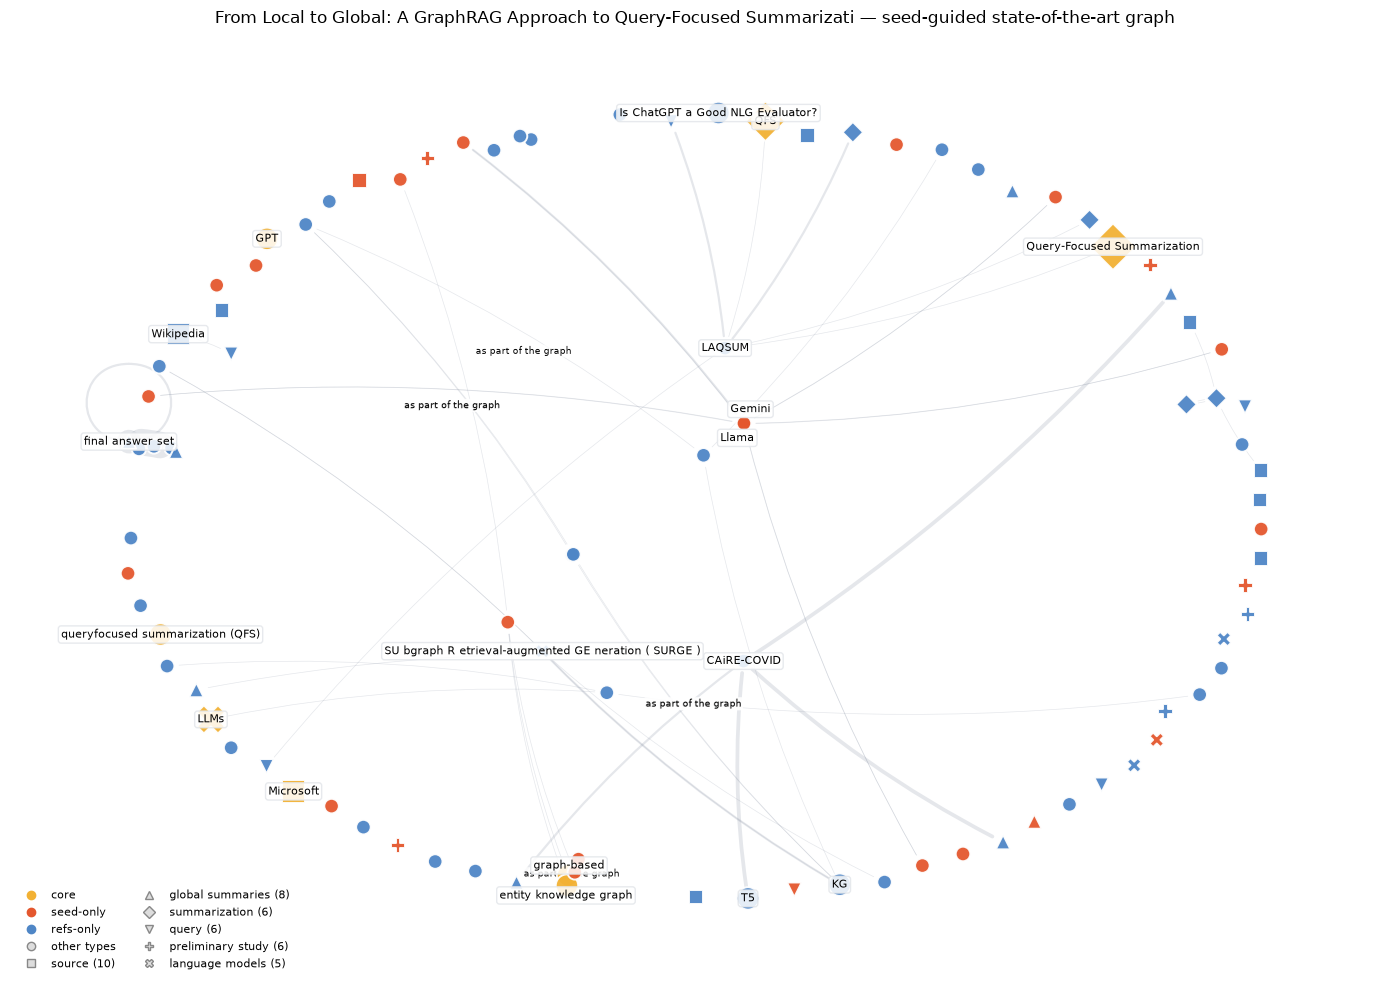

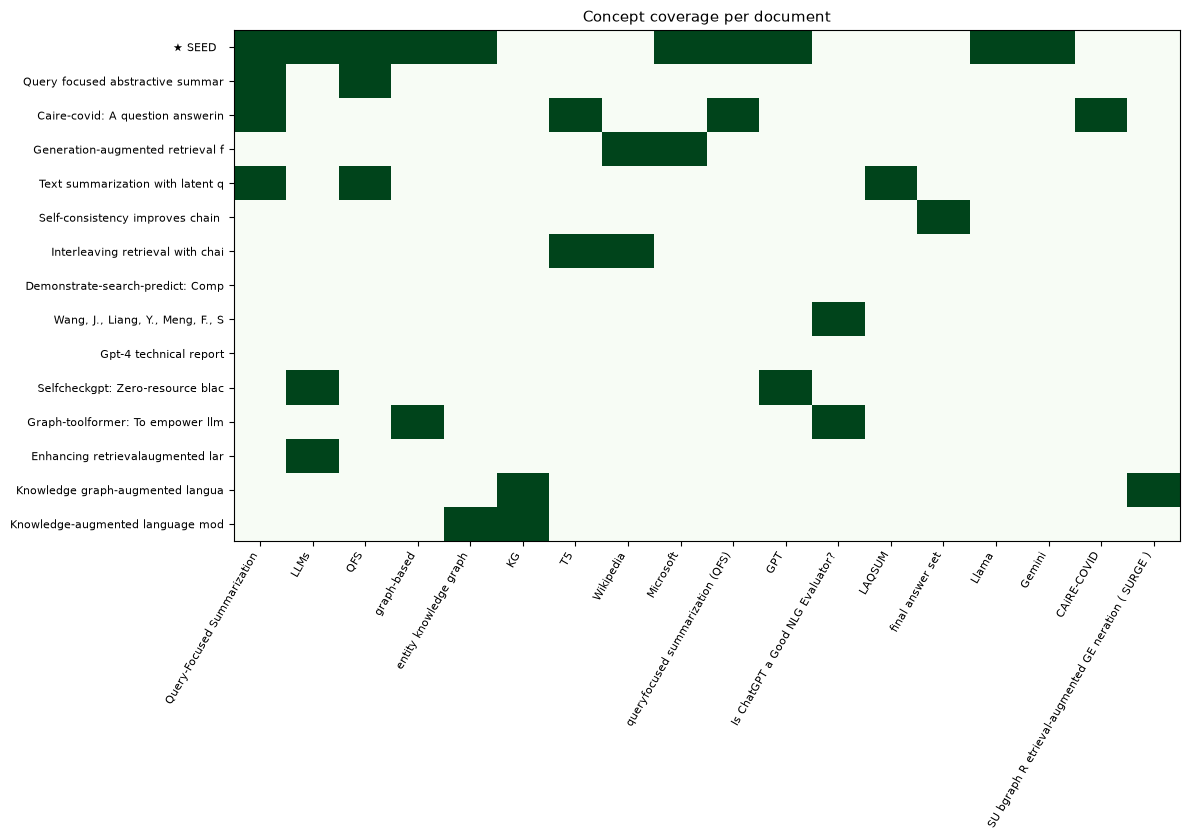

In [9]:
colors = {"core": "#f2b134", "seed-only": "#e4572e", "refs-only": "#4f86c6"}

def node_klass(nid):
    docs_of = {m["doc_id"] for m in kg.graph.nodes[nid]["mentions"]}
    return ("core" if (SEED_DOC_ID in docs_of and len(docs_of) > 1)
            else "seed-only" if SEED_DOC_ID in docs_of else "refs-only")

n = kg.graph.number_of_nodes()
pos = nx.spring_layout(kg.graph, k=2.6 / n ** 0.5, iterations=300, seed=42)

fig, ax = plt.subplots(figsize=(14, 10))
edge_w = [0.5 + 1.1 * (d.get("count", 1) - 1) for _, _, d in kg.graph.edges(data=True)]
nx.draw_networkx_edges(kg.graph, pos, ax=ax, width=edge_w, alpha=0.22, edge_color="#8a94a6",
                       arrows=True, arrowstyle="-", connectionstyle="arc3,rad=0.07")
node_colors = [colors[node_klass(nid)] for nid in kg.graph.nodes]
node_sizes = [110 + 150 * (len({m["doc_id"] for m in d["mentions"]}) - 1)
              for _, d in kg.graph.nodes(data=True)]

type_counts = Counter(d["entity_type"] for _, d in kg.graph.nodes(data=True))
top_types = [t for t, _ in type_counts.most_common(6)]
shape_for = dict(zip(top_types, ["s", "^", "D", "v", "P", "X"]))
marker_of = {nid: shape_for.get(kg.graph.nodes[nid]["entity_type"], "o") for nid in kg.graph.nodes}
sizes_of = dict(zip(kg.graph.nodes, node_sizes))
colors_of = dict(zip(kg.graph.nodes, node_colors))

for mk in "os^DvPX":
    nids = [nid for nid in kg.graph.nodes if marker_of[nid] == mk]
    if not nids:
        continue
    nx.draw_networkx_nodes(kg.graph, pos, ax=ax, nodelist=nids, node_shape=mk,
                           node_color=[colors_of[nid] for nid in nids],
                           node_size=[sizes_of[nid] for nid in nids],
                           linewidths=1.4, edgecolors="white", alpha=0.95)

def spread(points, min_d, iters=80):
    pts = {k: list(v) for k, v in points.items()}
    keys = list(pts)
    for _ in range(iters):
        moved = False
        for i in range(len(keys)):
            for j in range(i + 1, len(keys)):
                a, b = pts[keys[i]], pts[keys[j]]
                dx, dy = b[0] - a[0], b[1] - a[1]
                dist = max((dx * dx + dy * dy) ** 0.5, 1e-6)
                if dist < min_d:
                    f = (min_d - dist) / dist * 0.5
                    a[0] -= dx * f; a[1] -= dy * f
                    b[0] += dx * f; b[1] += dy * f
                    moved = True
        if not moved:
            break
    return {k: tuple(v) for k, v in pts.items()}

top_labels = df_nodes.head(18)["concept"].tolist()
lab_nids = [nid for nid, d in kg.graph.nodes(data=True) if d["text"] in set(top_labels)]
lab_pos = spread({nid: pos[nid] for nid in lab_nids}, min_d=0.075)
nx.draw_networkx_labels(kg.graph, lab_pos,
                        labels={nid: kg.graph.nodes[nid]["text"] for nid in lab_nids},
                        font_size=8, ax=ax,
                        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#e3e6ea", alpha=0.85))

strong = df_edges.head(6)
edge_labels = {(u, v): d.get("relation_type") for u, v, d in kg.graph.edges(data=True)
               if (kg.graph.nodes[u]["text"], d.get("relation_type"), kg.graph.nodes[v]["text"])
               in set(zip(strong["head"], strong["relation"], strong["tail"]))}
nx.draw_networkx_edge_labels(kg.graph, pos, edge_labels=edge_labels, font_size=6.5, ax=ax,
                             label_pos=0.45, rotate=False,
                             bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75))

handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=k) for k, c in colors.items()]
handles.append(plt.Line2D([], [], marker="o", ls="", color="none",
                          markerfacecolor="#ddd", markeredgecolor="#888", label="other types"))
handles += [plt.Line2D([], [], marker=mk, ls="", color="none", markerfacecolor="#ddd",
                       markeredgecolor="#888", label=f"{t[:26]} ({type_counts[t]})")
            for t, mk in shape_for.items()]
ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=8, ncol=2)
ax.set_title(f"{seed_title[:70]} — seed-guided state-of-the-art graph", fontsize=12, pad=12)
ax.axis("off")
plt.tight_layout()
out_dir = Path("../output"); out_dir.mkdir(exist_ok=True)
fig.savefig(out_dir / "exp04_graph.png", dpi=160, bbox_inches="tight")
kg.export_to_json(str(out_dir / "exp04_kg.json"))
print(f"saved -> {out_dir / 'exp04_graph.png'} | {out_dir / 'exp04_kg.json'}")

# concept x document coverage matrix (seed first)
top_concepts = df_nodes.head(18)["concept"].tolist()
doc_order = [SEED_DOC_ID] + [r for r in ref_ids if r in docs]
text_to_id = {d["text"]: nid for nid, d in kg.graph.nodes(data=True)}
mat = [[1 if did in ({m["doc_id"] for m in kg.graph.nodes[text_to_id[ct]]["mentions"]} if ct in text_to_id else set()) else 0
        for ct in top_concepts] for did in doc_order]

fig2, ax2 = plt.subplots(figsize=(12, max(3, 0.5 * len(doc_order) + 1)))
ax2.imshow(mat, cmap="Greens", aspect="auto")
ax2.set_xticks(range(len(top_concepts)), top_concepts, rotation=60, ha="right", fontsize=8)
row_labels = [("★ SEED  " if did == SEED_DOC_ID else REFS_META.get(did, {}).get("title", did)[:32]) for did in doc_order]
ax2.set_yticks(range(len(doc_order)), row_labels, fontsize=8)
ax2.set_title("Concept coverage per document", fontsize=11)
plt.tight_layout()
plt.show()

## Takeaways ✍️

1. **The citations really do shape the lens.** Concepts extracted from *citing contexts* are the seed's vocabulary about its field — GLiNER then finds them (or not) in each reference, which is a much sharper question than generic topic discovery.
2. **core / seed-only / refs-only is a cheap originality proxy.** The `seed-only` class is literally the paper's claimed novelty surface; if it's empty, the paper may be more derivative than it sounds.
3. **Qwen 0.6b is the weakest link.** Expect noisy/duplicated labels; they only cost recall because GLiNER ignores labels that don't match anything. Swapping to `qwen3:4b` is one knob (`OLLAMA_MODEL`) and should tighten the taxonomy.
4. **Author–year matching is brittle** (initials-only cites, narrative cites like *"as Cheng et al. showed"* without year fall through) — ~85% coverage on this seed is fine for an experiment.
5. **No head-to-head against the current pipeline.** Comparing this graph with the repo's default-taxonomy route on the same corpus would double the GLiNER runtime and didn't fit this experiment's budget — left as future work.

### Next steps
- Compare this taxonomy against exp_02's KeyBERT/Qwen routes on the same seed.
- Recursion: run the same experiment treating each reference as a new seed → citation graph of graphs.
- Strengthen dangling nodes: mine candidate subject–verb–object links for isolated concepts with the spaCy `DependencyRelationExtractor` (exp_03), let Qwen name the promising ones as new relation labels, and re-run GLiNER with the expanded taxonomy so disconnected nodes get wired back into the graph.
- Swap `FETCH_MISSING=True` and grow past the local cache.

---

### Cleanup 🔌

Unload Qwen right now instead of waiting for the keep-alive TTL (`keep_alive=0`), and confirm nothing is resident:

In [10]:
bare = OLLAMA_MODEL.split("/")[-1]
r = requests.post(f"{OLLAMA_API_BASE}/api/generate", json={"model": bare, "keep_alive": 0}, timeout=60)
print(f"unload {bare} -> HTTP {r.status_code}")
loaded = requests.get(f"{OLLAMA_API_BASE}/api/ps", timeout=10).json().get("models", [])
print("models still loaded:", [m["name"] for m in loaded] or "none - VRAM free ✓")


def shutdown_ollama():
    proc = globals().get("_OLLAMA_PROC")
    if proc is not None and proc.poll() is None:
        proc.terminate()
        try:
            proc.wait(timeout=10)
            print(f"Ollama stopped ✓ (pid {proc.pid})")
        except subprocess.TimeoutExpired:
            proc.kill()
            proc.wait()
            print(f"Ollama force-killed ✓ (pid {proc.pid})")
        return
    try:
        requests.get(f"{OLLAMA_API_BASE}/api/tags", timeout=2).raise_for_status()
        print("⚠️  Ollama is still running outside this notebook.")
        print("    Close it manually if you want: pkill ollama   (or quit the Ollama app)")
    except requests.RequestException:
        print("Ollama not running - nothing to shut down")


shutdown_ollama()

unload qwen3:0.6b -> HTTP 200
models still loaded: none - VRAM free ✓
⚠️  Ollama is still running outside this notebook.
    Close it manually if you want: pkill ollama   (or quit the Ollama app)
